# Importing libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Loading dataset

In [2]:
df=pd.read_csv("data.csv")
df.head(8)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,Male,168,62,110,80,Normal,Normal,Non-Smoker,No Alcohol,Active,Healthy
1,1,20228,Female,156,85,140,90,Very High,Normal,Non-Smoker,No Alcohol,Active,At Risk
2,2,18857,Female,165,64,130,70,Very High,Normal,Non-Smoker,No Alcohol,Inactive,At Risk
3,3,17623,Male,169,82,150,100,Normal,Normal,Non-Smoker,No Alcohol,Active,At Risk
4,4,17474,Female,156,56,100,60,Normal,Normal,Non-Smoker,No Alcohol,Inactive,Healthy
5,8,21914,Female,151,67,120,80,High,Above Normal,Non-Smoker,No Alcohol,Inactive,Healthy
6,9,22113,Female,157,93,130,80,Very High,Normal,Non-Smoker,No Alcohol,Active,Healthy
7,12,22584,Male,178,95,130,90,Very High,Well Above Normal,Non-Smoker,No Alcohol,Active,At Risk


In [3]:
df.tail(6)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69994,99992,21074,Female,165,80,150,80,Normal,Normal,Non-Smoker,No Alcohol,Active,At Risk
69995,99993,19240,Male,168,76,120,80,Normal,Normal,Smoker,No Alcohol,Active,Healthy
69996,99995,22601,Female,158,126,140,90,High,Above Normal,Non-Smoker,No Alcohol,Active,At Risk
69997,99996,19066,Male,183,105,180,90,Very High,Normal,Non-Smoker,Alcohol,Inactive,At Risk
69998,99998,22431,Female,163,72,135,80,Normal,Above Normal,Non-Smoker,No Alcohol,Inactive,At Risk
69999,99999,20540,Female,170,72,120,80,High,Normal,Non-Smoker,No Alcohol,Active,Healthy


# Convert age from days to years

In [4]:
df['age']

0        18393
1        20228
2        18857
3        17623
4        17474
         ...  
69995    19240
69996    22601
69997    19066
69998    22431
69999    20540
Name: age, Length: 70000, dtype: int64

In [5]:
df['age'] = (df['age'] / 365.25).round().astype(int)
print("Updated 'age' column from days to years.\n")
df['age'].head(10)

Updated 'age' column from days to years.



0    50
1    55
2    52
3    48
4    48
5    60
6    61
7    62
8    48
9    54
Name: age, dtype: int32

# Cleaning the Blood Pressure columns 


In [6]:
df['ap_hi'].head(10)


0    110
1    140
2    130
3    150
4    100
5    120
6    130
7    130
8    110
9    110
Name: ap_hi, dtype: int64

In [7]:
df['ap_lo']

0         80
1         90
2         70
3        100
4         60
        ... 
69995     80
69996     90
69997     90
69998     80
69999     80
Name: ap_lo, Length: 70000, dtype: int64

In [8]:
print("Original DataFrame shape:", df.shape)
df.drop(df[(df['ap_hi'] > df['ap_lo']) | (df['ap_hi'] < 60) | (df['ap_hi'] > 250) | (df['ap_lo'] < 40) | (df['ap_lo'] > 200)].index, inplace=True)

print("Cleaned blood pressure values.")
df['ap_hi'].head(10).tail(5)


Original DataFrame shape: (70000, 13)
Cleaned blood pressure values.


3623    80
4825    90
4830    70
4941    80
5121    90
Name: ap_hi, dtype: int64

In [9]:
df['ap_lo'].head(10).tail(5)

3623    120
4825    140
4830    100
4941    170
5121    140
Name: ap_lo, dtype: int64

# Remove Duplicates 

In [10]:
dup = df.duplicated().sum()
if dup > 0:
    print(f"Found and removed {dup} duplicate rows.\n")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate rows found.\n")

No duplicate rows found.



In [11]:
print("Descriptive Statistics After Cleaning ")
print(df.describe())


Descriptive Statistics After Cleaning 
                 id         age      height      weight       ap_hi  \
count    103.000000  103.000000  103.000000  103.000000  103.000000   
mean   47661.941748   52.932039  164.728155   76.854369   87.087379   
std    28680.157011    6.673421    9.163220   13.993982   15.788496   
min      681.000000   39.000000  148.000000   51.000000   70.000000   
25%    21848.000000   48.000000  158.000000   66.500000   80.000000   
50%    47851.000000   53.000000  164.000000   75.000000   80.000000   
75%    70110.500000   58.000000  171.500000   84.500000   90.000000   
max    97210.000000   64.000000  188.000000  120.000000  170.000000   

            ap_lo  
count  103.000000  
mean   131.165049  
std     21.180872  
min     95.000000  
25%    120.000000  
50%    130.000000  
75%    140.000000  
max    190.000000  


In [12]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
474,681,52,Female,156,65,120,150,High,Normal,Non-Smoker,No Alcohol,Active,Healthy
636,913,56,Male,169,68,70,110,Normal,Normal,Non-Smoker,No Alcohol,Active,Healthy
2384,3356,64,Female,154,102,90,150,Normal,Normal,Non-Smoker,No Alcohol,Inactive,At Risk
2990,4214,60,Male,182,90,80,140,Very High,Well Above Normal,Non-Smoker,No Alcohol,Active,At Risk
3447,4880,55,Male,180,80,80,125,Very High,Well Above Normal,Smoker,Alcohol,Active,At Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66118,94387,56,Female,154,72,95,160,Very High,Well Above Normal,Non-Smoker,Alcohol,Active,At Risk
66657,95164,53,Male,160,81,80,120,Very High,Well Above Normal,Smoker,Alcohol,Active,At Risk
67421,96271,64,Female,153,74,80,130,Normal,Normal,Non-Smoker,No Alcohol,Active,At Risk
67470,96339,58,Male,172,57,80,120,Normal,Normal,Smoker,No Alcohol,Active,At Risk


In [13]:
cleaned_data= 'cleaned_cardio_data.csv'
df.to_csv(cleaned_data, index=False)

print("Dataset cleaned and saved to cleaned_data")
print(df.head())

Dataset cleaned and saved to cleaned_data
        id  age  gender  height  weight  ap_hi  ap_lo cholesterol  \
474    681   52  Female     156      65    120    150        High   
636    913   56    Male     169      68     70    110      Normal   
2384  3356   64  Female     154     102     90    150      Normal   
2990  4214   60    Male     182      90     80    140   Very High   
3447  4880   55    Male     180      80     80    125   Very High   

                   gluc       smoke        alco    active   cardio  
474              Normal  Non-Smoker  No Alcohol    Active  Healthy  
636              Normal  Non-Smoker  No Alcohol    Active  Healthy  
2384             Normal  Non-Smoker  No Alcohol  Inactive  At Risk  
2990  Well Above Normal  Non-Smoker  No Alcohol    Active  At Risk  
3447  Well Above Normal      Smoker     Alcohol    Active  At Risk  



# Bivariate and Multivariate Analysis 

 # 1. Correlation Matrix and Heatmap

 Correlation Heatmap 


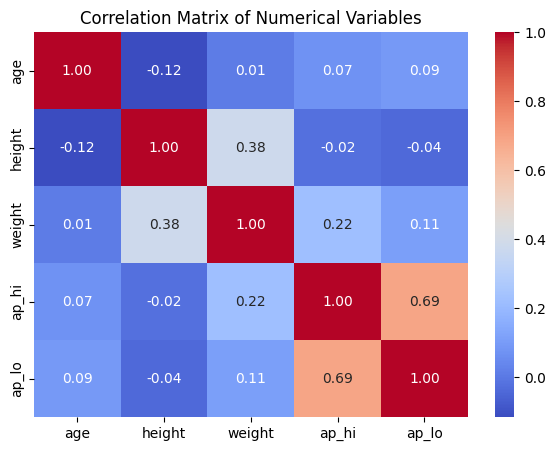

In [14]:
print(" Correlation Heatmap ")
num_df = df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']]
# Calculate the correlation matrix
corr_matrix = num_df.corr()
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# 2. Scatter Plot 

Scatter Plot: Weight vs. Height 


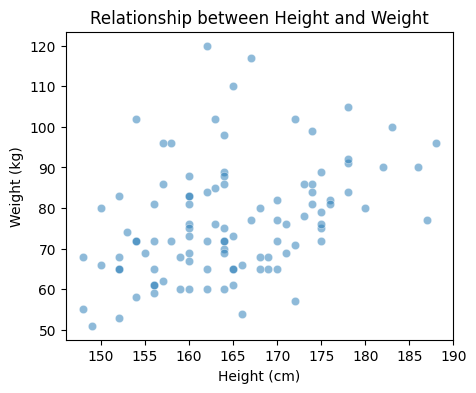

In [15]:

print("Scatter Plot: Weight vs. Height ")
plt.figure(figsize=(5, 4))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.5)
plt.title('Relationship between Height and Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# 3. Grouped Boxplot

In [16]:
print("Cardio Categories:", df['cardio'].unique())

Cardio Categories: ['Healthy' 'At Risk']


Boxplot: Age Distribution by Cardio Risk 


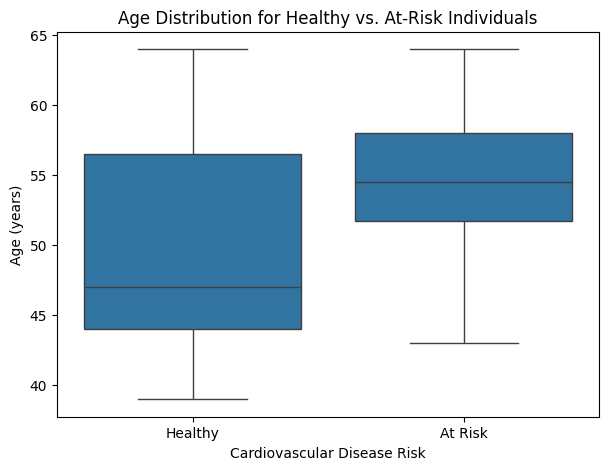

In [17]:
print("Boxplot: Age Distribution by Cardio Risk ")
plt.figure(figsize=(7, 5))
sns.boxplot(x='cardio', y='age', data=df)
plt.title('Age Distribution for Healthy vs. At-Risk Individuals')
plt.xlabel('Cardiovascular Disease Risk')
plt.ylabel('Age (years)')
plt.show()

# 4. Countplot for Categorical Variables 

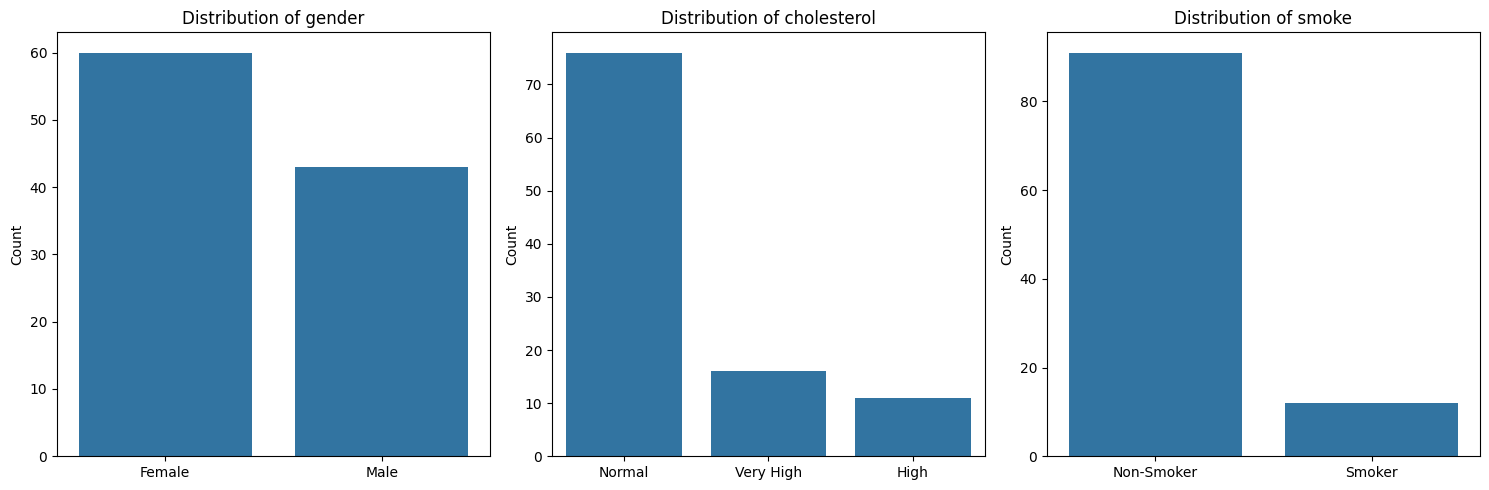

In [18]:
col = ['gender', 'cholesterol', 'smoke']
plt.figure(figsize=(15, 5))
for i, col in enumerate(col):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title('Distribution of ' + col) 
    plt.xlabel('')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#  5.Violin Plot: Blood Pressure vs. Cholesterol 

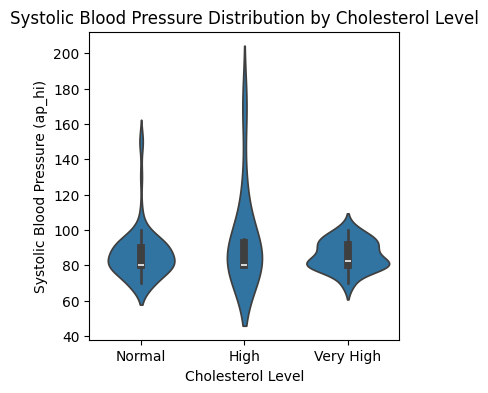

In [19]:
plt.figure(figsize=(4, 4))
sns.violinplot(x='cholesterol', y='ap_hi', data=df, order=['Normal', 'High', 'Very High'])
plt.title('Systolic Blood Pressure Distribution by Cholesterol Level')
plt.xlabel('Cholesterol Level')
plt.ylabel('Systolic Blood Pressure (ap_hi)')
plt.show()

#  Pairplot of Numerical Variables by Cardio Risk 

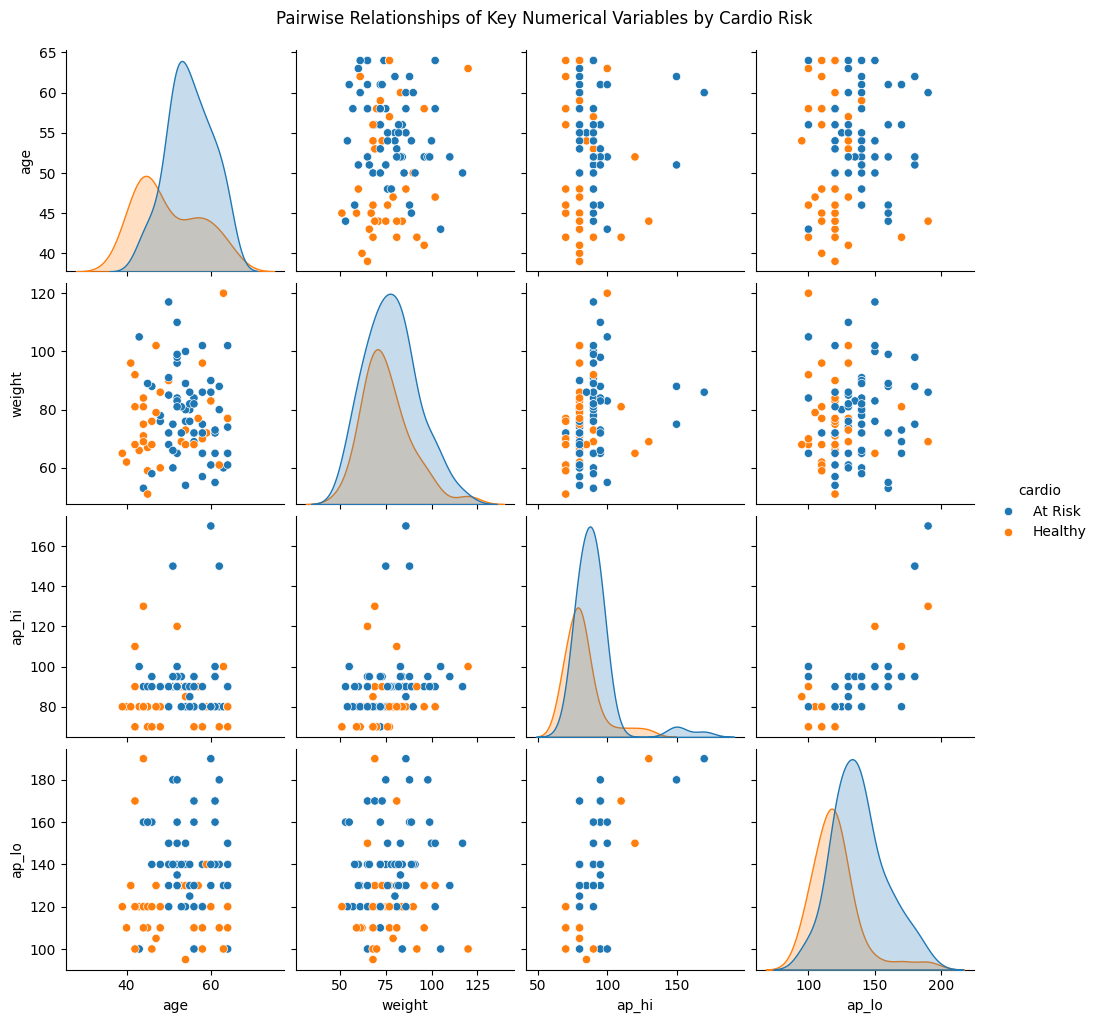

In [20]:
df_sample = df.sample(n=100, random_state=42)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
sns.pairplot(df_sample, vars=['age', 'weight', 'ap_hi', 'ap_lo'], hue='cardio', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Key Numerical Variables by Cardio Risk', y=1.02)
plt.show()

# Conclusion: Key Insights from the Analysis
This Exploratory Data Analysis of the cardiovascular disease dataset has revealed several key insights into the factors associated with cardiovascular risk. After cleaning the data and creating a wide range of visualizations to explore the relationships between variables, the following are the most significant findings:

1. Age and Blood Pressure are Primary Risk Indicators
Age and systolic blood pressure (ap_hi) are standout predictors of cardiovascular risk. The visualizations consistently show that individuals in the "At Risk" category are, on average, older and have higher blood pressure than their "Healthy" counterparts. The pairplot powerfully illustrates this, where the distributions for age and ap_hi for the at-risk group are visibly shifted towards higher values. The clear separation between the "Healthy" and "At Risk" clusters in the scatter plot of age versus systolic blood pressure confirms that this combination of factors is strongly associated with a higher likelihood of disease.

2. Interconnectedness of Weight, Cholesterol, and Blood Pressure
The analysis reveals that key health metrics are not independent but are closely linked. The violin plot shows a distinct trend where higher levels of cholesterol are associated with not only a higher median systolic blood pressure but also a wider, more volatile range of readings. Similarly, the correlation heatmap and pairplot highlight a moderate positive correlation between weight and blood pressure. This web of interconnected factors suggests that an increase in one metric, like cholesterol or weight, is often linked with a detrimental change in others, compounding the overall cardiovascular risk.

3. Lifestyle and Demographic Factors
The categorical analysis provides important context about the dataset's population. The countplots show a high prevalence of individuals with "High" or "Very High" cholesterol levels, which our other charts have identified as a significant risk factor. While smokers are a minority in this dataset, understanding the distribution of such lifestyle choices is crucial for building a complete picture of public health. These visualizations lay the groundwork for more advanced modeling to determine the precise impact of lifestyle factors on cardiovascular health.

#                        THANK YOU